## Linear regression example

### Prepare data

In a federated linear regression, each local site transmits its sufficient statistics $(\mathbf{X}^\top \mathbf{X}, \mathbf{X}^\top \mathbf{y}, \mathbf{y}^\top \mathbf{y}, n)$ to the central server. Let's assume the central server collects these sufficient statistics in a nested list object called `summary_stats`, each entry representing one local site and containing another list with entries `xx`, `xy`, `yy` and `n`.

As a demonstration, we will use the `nurses hom` synthetic test data set from the `confeR` package. It contains the (simulated) individual participant data (IPD) from 25 hospitals and the summary statistics transmitted by each hospital.

In [6]:
library(confeR)

data(nurses_hom, package = "confeR")
data <- nurses_hom$data_ipd
summary_stats <- nurses_hom$summary_stats

# if true, use fixed-effects local intercepts for each site; else use one global intercept
# best practice: first set to false, then assess heterogeneity with predictive check
# if heterogeneity present, re-run analysis with local intercepts
use_local_intercepts <- FALSE

In [7]:
# Inspect the summary statistics from the first hospital
summary_stats[[1]]

$xx
           Intercept       age    gender  wardtype experience
Intercept  41.000000  7.640903 22.000000 17.000000   4.306097
age         7.640903 32.596424  4.000946  6.870789   4.856068
gender     22.000000  4.000946 22.000000  9.000000   5.740959
wardtype   17.000000  6.870789  9.000000 17.000000  -2.179114
experience  4.306097  4.856068  5.740959 -2.179114  28.338100

$xy
                  [,1]
Intercept   -9.7900633
age          0.6060755
gender     -13.4555082
wardtype    -4.4388355
experience -18.2877613

$yy
         [,1]
[1,] 44.93776

$n
[1] 41

### Perform conjugate federated analysis

In [8]:
params_oneshot <- bca_oneshot(summary_stats, use_local_intercepts, family="gaussian")
df_bca <- tidy_results(params_oneshot, use_local_intercepts)
df_bca

Method,Covariate,Estimate,lower,upper
<chr>,<chr>,<dbl>,<dbl>,<dbl>
BCA,(Intercept),0.43115092,0.3246986,0.5376032
BCA,age,0.26965614,0.2067120,0.3326003
BCA,gender,-0.54685291,-0.6715928,-0.4221130
BCA,wardtype,-0.01006702,-0.1351289,0.1149949
BCA,experience,-0.41573823,-0.4793343,-0.3521421
BCA,sigma2,1.01095221,0.9276831,1.1060180


### Reverse-Bayes predictive check

In [9]:
model <- stress ~ gender + age + experience + wardtype
covariates <- attr(terms(model), "term.labels")
center_name <- "hospital"
box_results <- box_check_all_sites(params_oneshot, summary_stats, "gaussian", covariates,
                                  use_local_intercepts, center_name, remove_intercept = use_local_intercepts)

Warning message in match(df_forest$site, p_box_df_right$site, nomatch = Inf):
“NAs introduced by coercion to integer range”


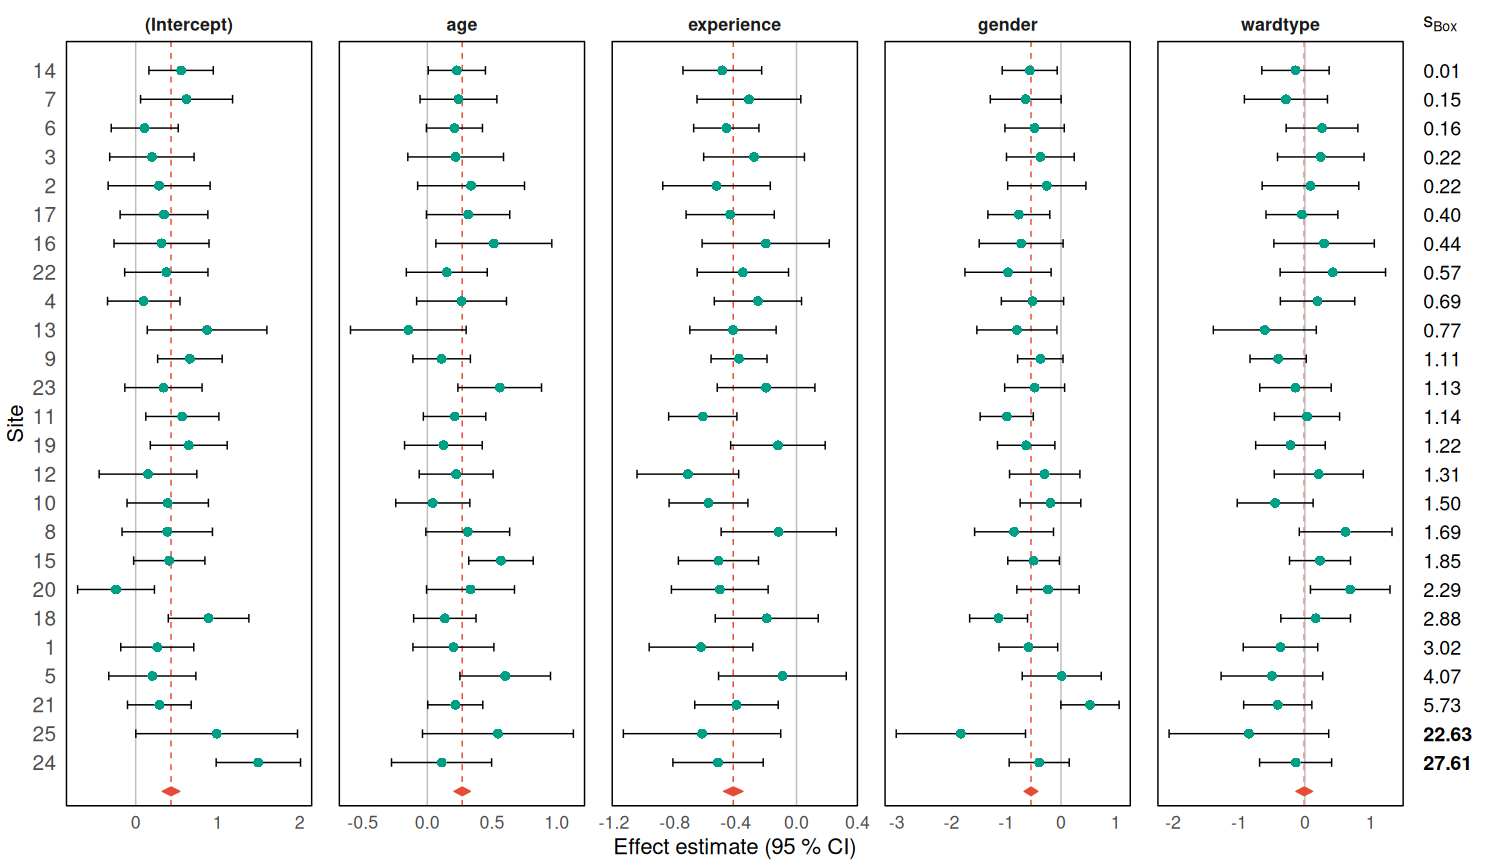

In [10]:
df_forest <- prepare_forest_plot(df_bca, summary_stats, alpha=0.05, family="gaussian")
df_forest <- df_forest |> dplyr::filter(df_forest$Covariate != "sigma2")
forest_plot(df_forest, box_results$pboxes, inline_plot = TRUE, use_log_scale = TRUE, order_box = TRUE)

### Computing summary statistics from IPD

If, for whatever reason (e.g. when using synthetic data), IPD is available and you wish to compute the summary statistics for each local site, the code below can be used.

In [13]:
library(dplyr)

# name of the column representing the local site ID
center_name <- "hospital"

# model for lm() regression
model <- stress ~ gender + age + experience + wardtype

data_split <- data |>
  group_by(.data[[center_name]]) |>
  group_split()

outcome <- all.vars(model)[1]
covariates <- attr(terms(model), "term.labels")
summary_stats <- lapply(seq_along(data_split), function(i) {
    bayes_lin_reg_stats(data_split[[i]], outcome, covariates,
                        k = if (use_local_intercepts) i else 0,
                        n_sites = length(data_split))
})

## GLM regression example

In [12]:
# TO DO